# Round 4 Strategy Research Notebook

Restricted to actual products:

- `HYDROGEL_PACK`
- `VELVETFRUIT_EXTRACT`
- `VEV_*` vouchers

The notebook tests products and voucher strategies separately, then ranks what is worth porting into the live trader.

In [57]:
from __future__ import annotations

import os, glob, math, json
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

HYD = "HYDROGEL_PACK"
VFE = "VELVETFRUIT_EXTRACT"
VOUCHERS = [
    "VEV_4000", "VEV_4500", "VEV_5000", "VEV_5100", "VEV_5200",
    "VEV_5300", "VEV_5400", "VEV_5500", "VEV_6000", "VEV_6500",
]
ALL_PRODUCTS = [HYD, VFE] + VOUCHERS
CAPS = {HYD: 200, VFE: 200, **{v: 300 for v in VOUCHERS}}

DATA_DIR = "."  # change to your Round 4 CSV folder

PRICE_PATTERNS = [
    "prices_round_4_day_*.csv",
]
TRADE_PATTERNS = [
    "trades_round_4_day_*.csv",
]

## 1. Load and clean Round 4 data

In [58]:
def _find_files(patterns: List[str], data_dir: str = DATA_DIR) -> List[str]:
    files = []
    for pat in patterns:
        files.extend(glob.glob(os.path.join(data_dir, pat)))
    return sorted(set(files))


def _read_csv_auto(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=";")
    if len(df.columns) <= 1:
        df = pd.read_csv(path)
    return df


def clean_prices(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    if "symbol" in df.columns and "product" not in df.columns:
        df = df.rename(columns={"symbol": "product"})
    if "product" not in df.columns:
        raise ValueError("Price dataframe needs product/symbol column")

    df = df[df["product"].isin(ALL_PRODUCTS)].copy()
    for c in df.columns:
        if c != "product":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if "day" not in df.columns:
        df["day"] = 0
    if "mid_price" not in df.columns:
        df["mid_price"] = (df["bid_price_1"] + df["ask_price_1"]) / 2

    df["spread"] = df["ask_price_1"] - df["bid_price_1"]
    bv1 = df["bid_volume_1"].fillna(0).abs()
    av1 = df["ask_volume_1"].fillna(0).abs()
    denom = bv1 + av1
    df["microprice"] = np.where(
        denom > 0,
        (df["ask_price_1"] * bv1 + df["bid_price_1"] * av1) / denom,
        df["mid_price"],
    )
    df["imbalance_l1"] = np.where(denom > 0, (bv1 - av1) / denom, 0.0)

    bv2 = sum(df[f"bid_volume_{i}"].fillna(0).abs() if f"bid_volume_{i}" in df else 0 for i in [1,2])
    av2 = sum(df[f"ask_volume_{i}"].fillna(0).abs() if f"ask_volume_{i}" in df else 0 for i in [1,2])
    denom2 = bv2 + av2
    df["imbalance_l2"] = np.where(denom2 > 0, (bv2 - av2) / denom2, 0.0)

    def wall_mid(row):
        bids, asks = [], []
        for i in [1,2,3]:
            bp, bv = row.get(f"bid_price_{i}"), row.get(f"bid_volume_{i}")
            ap, av = row.get(f"ask_price_{i}"), row.get(f"ask_volume_{i}")
            if pd.notna(bp) and pd.notna(bv): bids.append((float(bp), abs(float(bv))))
            if pd.notna(ap) and pd.notna(av): asks.append((float(ap), abs(float(av))))
        if not bids or not asks: return np.nan
        return 0.5 * (max(bids, key=lambda x:x[1])[0] + max(asks, key=lambda x:x[1])[0])

    df["wall_mid"] = df.apply(wall_mid, axis=1)
    return df.sort_values(["day", "timestamp", "product"]).reset_index(drop=True)


def clean_trades(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    if "symbol" in df.columns and "product" not in df.columns:
        df = df.rename(columns={"symbol": "product"})
    if "product" not in df.columns:
        return pd.DataFrame()
    df = df[df["product"].isin(ALL_PRODUCTS)].copy()
    for c in ["timestamp", "price", "quantity", "day"]:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    if "day" not in df.columns: df["day"] = 0
    for c in ["buyer", "seller"]:
        if c not in df.columns: df[c] = ""
        df[c] = df[c].fillna("").astype(str).str.strip()
    return df.sort_values(["day", "timestamp", "product"]).reset_index(drop=True)


def load_price_files(files: Optional[List[str]] = None, data_dir: str = DATA_DIR) -> pd.DataFrame:
    files = files or _find_files(PRICE_PATTERNS, data_dir)
    if not files:
        raise FileNotFoundError("No price files found. Set DATA_DIR or pass files=[...]")
    frames = []
    for path in files:
        df = _read_csv_auto(path)
        if "day" not in df.columns:
            import re
            m = re.search(r"day[_\-]?(-?\d+)", os.path.basename(path), re.I)
            if m: df["day"] = int(m.group(1))
        frames.append(df)
    return clean_prices(pd.concat(frames, ignore_index=True))


def load_trade_files(files: Optional[List[str]] = None, data_dir: str = DATA_DIR) -> pd.DataFrame:
    files = files or _find_files(TRADE_PATTERNS, data_dir)
    if not files:
        print("No trade files found; counterparty tests skipped.")
        return pd.DataFrame()
    frames = []
    for path in files:
        df = _read_csv_auto(path)
        if "day" not in df.columns:
            import re
            m = re.search(r"day[_\-]?(-?\d+)", os.path.basename(path), re.I)
            if m: df["day"] = int(m.group(1))
        frames.append(df)
    return clean_trades(pd.concat(frames, ignore_index=True))

# Usage:
# prices = load_price_files()
# trades = load_trade_files()
# display(prices.head())

## 2. Black-Scholes and feature helpers

In [59]:
SQRT2 = math.sqrt(2.0)
SQRT_2PI = math.sqrt(2.0 * math.pi)

def ncdf(x): return 0.5 * (1.0 + math.erf(x / SQRT2))
def npdf(x): return math.exp(-0.5 * x * x) / SQRT_2PI

def bs_call_price(s, k, t, sigma, r=0.0):
    if t <= 0 or sigma <= 0 or s <= 0 or k <= 0: return max(s-k, 0.0)
    vs = sigma * math.sqrt(t)
    d1 = (math.log(s/k) + (r + 0.5*sigma*sigma)*t) / vs
    d2 = d1 - vs
    return s * ncdf(d1) - k * math.exp(-r*t) * ncdf(d2)

def bs_call_delta(s, k, t, sigma, r=0.0):
    if t <= 0 or sigma <= 0 or s <= 0 or k <= 0: return 1.0 if s > k else 0.0
    vs = sigma * math.sqrt(t)
    d1 = (math.log(s/k) + (r + 0.5*sigma*sigma)*t) / vs
    return ncdf(d1)

def bs_call_vega(s, k, t, sigma, r=0.0):
    if t <= 0 or sigma <= 0 or s <= 0 or k <= 0: return 0.0
    vs = sigma * math.sqrt(t)
    d1 = (math.log(s/k) + (r + 0.5*sigma*sigma)*t) / vs
    return s * npdf(d1) * math.sqrt(t)

def implied_vol_call(price, s, k, t):
    if pd.isna(price) or pd.isna(s) or pd.isna(k) or pd.isna(t) or price <= 0 or s <= 0 or k <= 0 or t <= 0:
        return np.nan
    intrinsic = max(s-k, 0.0)
    if price < intrinsic - 1e-9 or price > s + 1e-9:
        return np.nan
    if abs(price - intrinsic) < 1e-9:
        return 1e-6
    lo, hi = 1e-6, 5.0
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        if bs_call_price(s, k, t, mid) > price:
            hi = mid
        else:
            lo = mid
    return 0.5 * (lo + hi)

def strike_from_symbol(sym):
    return int(str(sym).split("_")[1]) if str(sym).startswith("VEV_") else None

def tte_years(timestamp, start_days=6.0, day_ticks=1_000_000.0, floor_days=0.25):
    return max(start_days - timestamp / day_ticks, floor_days) / 365.0

def max_drawdown(series):
    if len(series) == 0: return 0.0
    return float((series - series.cummax()).min())

## 3. Diagnostics: mean-reversion, trend, microprice predictiveness

In [60]:
def add_forward_returns(prices, horizons=(1,5,10,20,50,100,1000)):
    df = prices.copy().sort_values(["day", "product", "timestamp"])
    for h in horizons:
        df[f"fwd_mid_{h}"] = df.groupby(["day", "product"])["mid_price"].shift(-h)
        df[f"fwd_ret_{h}"] = df[f"fwd_mid_{h}"] - df["mid_price"]
    return df


def diagnostic_table(prices, products=ALL_PRODUCTS, horizons=(1,5,10,20,50,100)):
    df = add_forward_returns(prices, horizons)
    rows = []
    for prod in products:
        x = df[df["product"] == prod]
        if x.empty: continue
        row = {
            "product": prod,
            "n": len(x),
            "mid_mean": x.mid_price.mean(),
            "mid_std": x.mid_price.std(),
            "avg_spread": x.spread.mean(),
            "micro_minus_mid": (x.microprice - x.mid_price).mean(),
        }
        for h in horizons:
            y = x.dropna(subset=[f"fwd_ret_{h}"])
            if len(y) > 20:
                row[f"imb_corr_{h}"] = y.imbalance_l2.corr(y[f"fwd_ret_{h}"])
                row[f"micro_corr_{h}"] = (y.microprice - y.mid_price).corr(y[f"fwd_ret_{h}"])
        rows.append(row)
    return pd.DataFrame(rows).sort_values("product")


def plot_product(prices, product):
    x = prices[prices["product"] == product]
    for day, g in x.groupby("day"):
        plt.figure(figsize=(12,4))
        plt.plot(g.timestamp, g.mid_price, label="mid")
        if product == HYD: plt.axhline(10000, linestyle="--", label="10000")
        plt.title(f"{product} day {day}")
        plt.legend(); plt.show()

# display(diagnostic_table(prices))
# plot_product(prices, HYD)
# plot_product(prices, VFE)

## 4. Simple backtest engine

In [61]:
@dataclass
class BTResult:
    name: str
    product: str
    total_pnl: float
    per_day: Dict[int, float]
    trades: int
    max_abs_pos: int
    max_dd: float
    equity: pd.DataFrame
    params: Dict


def buy_room(pos, cap, desired): return max(0, min(int(desired), cap - pos))
def sell_room(pos, cap, desired): return max(0, min(int(desired), cap + pos))


def run_single_product_strategy(prices, product, signal_func, name, cap=None, params=None):
    params = params or {}
    cap = cap or CAPS.get(product, 100)
    df = prices[prices["product"] == product].sort_values(["day", "timestamp"])
    cash = 0.0; pos = 0; trades = 0; max_abs_pos = 0
    state = {}; eq_rows = []; day_start = {}
    for _, row in df.iterrows():
        day = int(row.day)
        if day not in day_start:
            day_start[day] = cash + pos * row.mid_price
        desired = int(signal_func(row, pos, state, params))
        if desired > 0 and pd.notna(row.ask_price_1):
            avail = int(abs(row.ask_volume_1)) if pd.notna(row.ask_volume_1) else desired
            qty = buy_room(pos, cap, min(desired, avail))
            if qty > 0:
                cash -= qty * row.ask_price_1; pos += qty; trades += 1
        elif desired < 0 and pd.notna(row.bid_price_1):
            avail = int(abs(row.bid_volume_1)) if pd.notna(row.bid_volume_1) else -desired
            qty = sell_room(pos, cap, min(-desired, avail))
            if qty > 0:
                cash += qty * row.bid_price_1; pos -= qty; trades += 1
        equity = cash + pos * row.mid_price
        max_abs_pos = max(max_abs_pos, abs(pos))
        eq_rows.append({"day": day, "timestamp": row.timestamp, "equity": equity, "pos": pos})
    eq = pd.DataFrame(eq_rows)
    total = float(eq.equity.iloc[-1]) if len(eq) else 0.0
    per_day = {int(d): float(g.equity.iloc[-1] - day_start[int(d)]) for d, g in eq.groupby("day")} if len(eq) else {}
    return BTResult(name, product, total, per_day, trades, max_abs_pos, max_drawdown(eq.equity if len(eq) else pd.Series(dtype=float)), eq, params)


def summarize_results(results):
    rows = []
    for r in results:
        row = {"strategy": r.name, "product": r.product, "total_pnl": r.total_pnl,
               "trades": r.trades, "max_abs_pos": r.max_abs_pos, "max_drawdown": r.max_dd,
               "params": r.params}
        for d, pnl in r.per_day.items(): row[f"day_{d}_pnl"] = pnl
        rows.append(row)
    return pd.DataFrame(rows).sort_values("total_pnl", ascending=False).reset_index(drop=True) if rows else pd.DataFrame()


def plot_equity(result):
    plt.figure(figsize=(12,4))
    plt.plot(result.equity.index, result.equity.equity)
    plt.title(f"{result.name} {result["product"]}: {result.total_pnl:.1f}")
    plt.show()

## 5. HYDROGEL strategy sweeps

In [62]:
def hyd_anchor_signal(row, pos, state, p):
    fair = p.get("anchor", 10000.0) - p.get("inv_skew", 0.02) * pos
    edge = p.get("edge", 4.0); size = p.get("size", 20)
    if row.ask_price_1 < fair - edge: return size
    if row.bid_price_1 > fair + edge: return -size
    return 0


def hyd_ema_signal(row, pos, state, p):
    alpha = p.get("alpha", 0.08); anchor_w = p.get("anchor_w", 0.35)
    obs = anchor_w * 10000 + (1-anchor_w) * row.microprice
    prev = state.get("fair")
    fair = obs if prev is None else (1-alpha)*prev + alpha*obs
    state["fair"] = fair
    fair -= p.get("inv_skew", 0.02) * pos
    edge = p.get("edge", 4.0); size = p.get("size", 20)
    if row.ask_price_1 < fair - edge: return size
    if row.bid_price_1 > fair + edge: return -size
    return 0


def hyd_wall_micro_signal(row, pos, state, p):
    alpha = p.get("alpha", 0.08); anchor_w = p.get("anchor_w", 0.35); wall_w = p.get("wall_w", 0.9)
    book = row.microprice if pd.isna(row.wall_mid) else wall_w * row.wall_mid + (1-wall_w) * row.microprice
    obs = anchor_w * 10000 + (1-anchor_w) * book
    prev = state.get("fair")
    fair = obs if prev is None else (1-alpha)*prev + alpha*obs
    state["fair"] = fair
    fair -= p.get("inv_skew", 0.02) * pos
    edge = p.get("edge", 4.0); size = p.get("size", 20)
    if row.ask_price_1 < fair - edge: return size
    if row.bid_price_1 > fair + edge: return -size
    return 0


def sweep_hyd(prices):
    results = []
    for edge in [2,3,4,5,6,8,10,12]:
        for size in [5,10,20,40,80]:
            results.append(run_single_product_strategy(prices, HYD, hyd_anchor_signal, "HYD_anchor", params={"edge":edge,"size":size}))
            results.append(run_single_product_strategy(prices, HYD, hyd_ema_signal, "HYD_ema", params={"edge":edge,"size":size}))
            results.append(run_single_product_strategy(prices, HYD, hyd_wall_micro_signal, "HYD_wall_micro", params={"edge":edge,"size":size}))
    return summarize_results(results)

# hyd_results = sweep_hyd(prices)
# display(hyd_results.head(20))

## 6. VFE strategy sweeps and counterparty analysis

In [63]:
def vfe_ema_imb_signal(row, pos, state, p):
    alpha = p.get("alpha", 0.20)
    prev = state.get("fair")
    obs = row.microprice
    fair = obs if prev is None else (1-alpha)*prev + alpha*obs
    state["fair"] = fair
    skew = np.clip(p.get("imb_k", 0.0) * row.imbalance_l2, -p.get("skew_cap", 2.0), p.get("skew_cap", 2.0))
    fair = fair + skew - p.get("inv_skew", 0.02) * pos
    edge = p.get("edge", 1.0); size = p.get("size", 10)
    if row.ask_price_1 <= fair - edge: return size
    if row.bid_price_1 >= fair + edge: return -size
    return 0


def sweep_vfe(prices):
    results = []
    for edge in [0.5,1,1.5,2,3,4]:
        for size in [5,10,20,40]:
            for imb_k in [0,2,4,8,12]:
                results.append(run_single_product_strategy(prices, VFE, vfe_ema_imb_signal, "VFE_ema_imb", params={"edge":edge,"size":size,"imb_k":imb_k}))
    return summarize_results(results)


def counterparty_forward_returns(prices, trades, product=VFE, horizons=(1,5,10,20,50,100,1000)):
    if trades.empty: return pd.DataFrame()
    p = prices[prices["product"] == product][["day","timestamp","mid_price"]].sort_values(["day","timestamp"])
    t = trades[trades["product"] == product].sort_values(["day","timestamp"])
    rows = []
    for day, td in t.groupby("day"):
        pd_day = p[p.day == day].reset_index(drop=True)
        ts = pd_day.timestamp.values; mids = pd_day.mid_price.values
        for _, tr in td.iterrows():
            idx = np.searchsorted(ts, tr.timestamp, side="left")
            if idx >= len(ts): continue
            mid0 = mids[idx]
            pair = f"{tr.buyer}->{tr.seller}"
            for role, name, sign in [("buyer", tr.buyer, +1), ("seller", tr.seller, -1), ("pair", pair, +1)]:
                if not name or name == "->": continue
                rec = {"day": day, "product": product, "role": role, "name": name, "buyer": tr.buyer, "seller": tr.seller}
                for h in horizons:
                    rec[f"signed_ret_{h}"] = sign * (mids[idx+h] - mid0) if idx+h < len(mids) else np.nan
                rows.append(rec)
    ev = pd.DataFrame(rows)
    if ev.empty: return ev
    keys = ["product", "role", "name"]
    out = ev.groupby(keys).size().reset_index(name="n")
    for h in horizons:
        col = f"signed_ret_{h}"
        s = ev.groupby(keys)[col].agg(["mean","std","count"]).reset_index()
        s[f"t_{h}"] = s["mean"] / (s["std"] / np.sqrt(s["count"].clip(lower=1)))
        s = s.rename(columns={"mean":f"mean_{h}", "count":f"count_{h}"})
        out = out.merge(s[keys + [f"mean_{h}", f"t_{h}", f"count_{h}"]], on=keys, how="left")
    return out.sort_values("n", ascending=False)

# vfe_results = sweep_vfe(prices)
# display(vfe_results.head(20))
# display(counterparty_forward_returns(prices, trades, VFE).sort_values("t_20", ascending=False).head(30))

## 7. Build voucher panel with IV/smile features

In [64]:
def build_voucher_panel(prices, start_tte_days=6.0):
    vfe = prices[prices["product"] == VFE][["day","timestamp","mid_price","microprice"]].rename(columns={"mid_price":"S_mid","microprice":"S_micro"})
    rows = []
    for sym in VOUCHERS:
        k = strike_from_symbol(sym)
        x = prices[prices["product"] == sym].copy()
        if x.empty: continue
        x = x.merge(vfe, on=["day","timestamp"], how="left")
        x["strike"] = k
        x["tte"] = x.timestamp.apply(lambda ts: tte_years(ts, start_days=start_tte_days))
        x["intrinsic"] = np.maximum(x.S_mid - k, 0)
        x["moneyness"] = np.log(x.S_mid / k)
        x["iv"] = [implied_vol_call(px, s, k, t) for px, s, t in zip(x.mid_price, x.S_mid, x.tte)]
        rows.append(x)
    return pd.concat(rows, ignore_index=True).sort_values(["day","timestamp","strike"]) if rows else pd.DataFrame()


def fit_smile_by_timestamp(panel, min_points=4):
    rows = []
    p = panel.dropna(subset=["iv","moneyness"])
    p = p[(p.iv > 0.001) & (p.iv < 2.0)]
    for (day, ts), g in p.groupby(["day","timestamp"]):
        if len(g) < min_points: continue
        X = np.vstack([np.ones(len(g)), g.moneyness.values, g.moneyness.values**2]).T
        beta = np.linalg.lstsq(X, g.iv.values, rcond=None)[0]
        rows.append({"day":day,"timestamp":ts,"a0":beta[0],"a1":beta[1],"a2":beta[2],"n":len(g)})
    return pd.DataFrame(rows)


def attach_smile(panel, smile):
    out = panel.merge(smile, on=["day","timestamp"], how="left")
    out["smile_iv"] = out.a0 + out.a1*out.moneyness + out.a2*out.moneyness**2
    out["smile_fair"] = [bs_call_price(s,k,t,sig) if pd.notna(sig) else np.nan for s,k,t,sig in zip(out.S_mid,out.strike,out.tte,out.smile_iv)]
    out["smile_residual_px"] = out.mid_price - out.smile_fair
    out["smile_residual_iv"] = out.iv - out.smile_iv
    return out

# panel = build_voucher_panel(prices, start_tte_days=6.0)
# smile = fit_smile_by_timestamp(panel)
# panel = attach_smile(panel, smile)
# display(panel.head())

## 8. Voucher Strategy 1: Black-Scholes smile fair

In [65]:
def voucher_smile_signal(row, pos, state, p):
    fair = row.get("smile_fair", np.nan)
    if pd.isna(fair): return 0
    fair -= p.get("inv_skew", 0.01) * pos
    edge = p.get("edge", 1.0); size = p.get("size", 5)
    if row.ask_price_1 <= fair - edge: return size
    if row.bid_price_1 >= fair + edge: return -size
    return 0


def sweep_voucher_smile(panel):
    results = []
    for sym in VOUCHERS:
        if sym not in set(panel["product"]): continue
        for edge in [0.5,1,1.5,2,3,5,8]:
            for size in [1,2,5,10]:
                results.append(run_single_product_strategy(panel, sym, voucher_smile_signal, "voucher_smile", cap=300, params={"edge":edge,"size":size}))
    return summarize_results(results)

# smile_results = sweep_voucher_smile(panel)
# display(smile_results.head(30))

## 9. Voucher Strategy 2: intrinsic value arb

In [66]:
def voucher_intrinsic_signal(row, pos, state, p):
    intr = row.get("intrinsic", np.nan)
    if pd.isna(intr): return 0
    if row.ask_price_1 <= intr - p.get("buy_edge", 1.0): return p.get("size", 20)
    if pos > 0 and row.bid_price_1 >= intr + p.get("sell_edge", 2.0): return -min(pos, p.get("size", 20))
    return 0


def sweep_intrinsic(panel):
    results = []
    for sym in VOUCHERS:
        if sym not in set(panel["product"]): continue
        for buy_edge in [0,1,2,3,5,8,13]:
            for sell_edge in [1,2,4,8,13]:
                for size in [5,10,20,50]:
                    results.append(run_single_product_strategy(panel, sym, voucher_intrinsic_signal, "voucher_intrinsic", cap=300, params={"buy_edge":buy_edge,"sell_edge":sell_edge,"size":size}))
    return summarize_results(results)

# intrinsic_results = sweep_intrinsic(panel)
# display(intrinsic_results.head(30))

## 10. Voucher Strategy 3: cross-strike relative value diagnostics

In [67]:
def pair_residual_diagnostics(panel, pairs=None, horizons=(1,5,10,20,50,100)):
    pairs = pairs or [(5000,5100),(5100,5200),(5200,5300),(5300,5400),(5400,5500),(5500,6000)]
    p = panel.dropna(subset=["smile_residual_iv"])
    wide = p.pivot_table(index=["day","timestamp"], columns="strike", values="smile_residual_iv").reset_index()
    rows = []
    for k1,k2 in pairs:
        if k1 not in wide.columns or k2 not in wide.columns: continue
        x = wide[["day","timestamp",k1,k2]].dropna().copy()
        x["pair_res"] = x[k1] - x[k2]
        mu, sig = x.pair_res.mean(), x.pair_res.std()
        x["z"] = (x.pair_res - mu) / sig if sig > 0 else np.nan
        row = {"pair":f"{k1}-{k2}", "n":len(x), "mean":mu, "sigma":sig, "rho1":x.pair_res.autocorr(1)}
        for h in horizons:
            x[f"future_change_{h}"] = x.groupby("day").pair_res.shift(-h) - x.pair_res
            signed_reversion = -np.sign(x.z) * x[f"future_change_{h}"]
            row[f"mean_reversion_{h}"] = signed_reversion.mean()
            row[f"hit_rate_{h}"] = (signed_reversion > 0).mean()
        rows.append(row)
    return pd.DataFrame(rows).sort_values("mean_reversion_10", ascending=False)

# pair_diag = pair_residual_diagnostics(panel)
# display(pair_diag)

## 11. Voucher Strategy 4: delta-lag / option underreaction

In [68]:
def build_delta_lag_panel(panel, lag=1):
    p = panel.sort_values(["day","product","timestamp"]).copy()
    p["prev_S"] = p.groupby(["day","product"]).S_mid.shift(lag)
    p["prev_mid"] = p.groupby(["day","product"]).mid_price.shift(lag)
    p["dS"] = p.S_mid - p.prev_S
    p["dC"] = p.mid_price - p.prev_mid
    p["delta"] = [bs_call_delta(s,k,t,sig) if pd.notna(sig) else np.nan for s,k,t,sig in zip(p.S_mid,p.strike,p.tte,p.smile_iv)]
    p["expected_dC"] = p.delta * p.dS
    p["delta_lag_edge"] = p.expected_dC - p.dC
    return p


def delta_lag_signal(row, pos, state, p):
    edge = row.get("delta_lag_edge", np.nan)
    if pd.isna(edge): return 0
    if abs(row.get("dS", 0.0)) < p.get("min_abs_dS", 1.0): return 0
    if row.spread > p.get("max_spread", 2.0): return 0
    th = p.get("threshold", 1.5); size = p.get("size", 2)
    if edge > th: return size
    if edge < -th: return -size
    return 0


def sweep_delta_lag(panel):
    results = []
    for lag in [1,2,5,10]:
        lag_panel = build_delta_lag_panel(panel, lag=lag)
        for sym in VOUCHERS:
            if sym not in set(lag_panel["product"]): continue
            for threshold in [0.5,1,1.5,2,3,5]:
                for max_spread in [1,2,3,5]:
                    for size in [1,2,5]:
                        results.append(run_single_product_strategy(lag_panel, sym, delta_lag_signal, "delta_lag", cap=300, params={"lag":lag,"threshold":threshold,"max_spread":max_spread,"size":size}))
    return summarize_results(results)

# delta_results = sweep_delta_lag(panel)
# display(delta_results.head(30))

## 12. Option-implied VFE fair test

In [69]:
def implied_underlying_from_price(price, k, t, sigma, lo=1.0, hi=20000.0):
    if pd.isna(price) or pd.isna(sigma) or sigma <= 0: return np.nan
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if bs_call_price(mid, k, t, sigma) > price: hi = mid
        else: lo = mid
    return 0.5 * (lo + hi)


def option_implied_vfe_table(panel):
    p = panel.dropna(subset=["smile_iv","mid_price","S_mid"]).copy()
    p["S_imp"] = [implied_underlying_from_price(px,k,t,sig) for px,k,t,sig in zip(p.mid_price,p.strike,p.tte,p.smile_iv)]
    p["vega"] = [bs_call_vega(s,k,t,sig) if pd.notna(s) and pd.notna(sig) else np.nan for s,k,t,sig in zip(p.S_imp,p.strike,p.tte,p.smile_iv)]
    rows = []
    for (day, ts), g in p.dropna(subset=["S_imp","vega"]).groupby(["day","timestamp"]):
        g = g[g.vega > 0.1]
        if len(g) < 2: continue
        w = g.vega.values
        S_cons = np.average(g.S_imp.values, weights=w)
        S_mkt = g.S_mid.iloc[0]
        disp = np.sqrt(np.average((g.S_imp.values - S_cons)**2, weights=w))
        conf = abs(S_cons - S_mkt) / disp if disp > 1e-9 else 0.0
        rows.append({"day":day,"timestamp":ts,"S_market":S_mkt,"S_consensus":S_cons,"edge":S_cons-S_mkt,"dispersion":disp,"confidence":conf,"n":len(g)})
    out = pd.DataFrame(rows)
    if out.empty: return out
    vfe = panel[["day","timestamp","S_mid"]].drop_duplicates().sort_values(["day","timestamp"])
    for h in [1,5,10,20,50,100]:
        vfe[f"ret_{h}"] = vfe.groupby("day").S_mid.shift(-h) - vfe.S_mid
    return out.merge(vfe[["day","timestamp"] + [f"ret_{h}" for h in [1,5,10,20,50,100]]], on=["day","timestamp"], how="left")

# opt_vfe = option_implied_vfe_table(panel)
# display(opt_vfe.head())
# for h in [1,5,10,20,50,100]:
#     print(h, opt_vfe.edge.corr(opt_vfe[f"ret_{h}"]))

## 13. Master run cell

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,microprice,imbalance_l1,imbalance_l2,wall_mid
0,1,0,HYDROGEL_PACK,9950,13,9947.0,23.0,NaN,NaN,9966,13,9968.0,23.0,NaN,NaN,9958.0,0.0,16,9958.00,0.00,0.0,9957.5
1,1,0,VELVETFRUIT_EXTRACT,5242,54,NaN,NaN,NaN,NaN,5248,54,NaN,NaN,NaN,NaN,5245.0,0.0,6,5245.00,0.00,0.0,5245.0
2,1,0,VEV_4000,1235,15,1232.0,27.0,NaN,NaN,1255,15,1258.0,27.0,NaN,NaN,1245.0,0.0,20,1245.00,0.00,0.0,1245.0
3,1,0,VEV_4500,737,6,735.0,13.0,NaN,NaN,753,6,755.0,13.0,NaN,NaN,745.0,0.0,16,745.00,0.00,0.0,745.0
4,1,0,VEV_5000,248,19,NaN,NaN,NaN,NaN,254,6,255.0,13.0,NaN,NaN,251.0,0.0,6,252.56,0.52,0.0,251.5


product
HYDROGEL_PACK          30000
VELVETFRUIT_EXTRACT    30000
VEV_4000               30000
VEV_4500               30000
VEV_5000               30000
VEV_5100               30000
VEV_5200               30000
VEV_5300               30000
VEV_5400               30000
VEV_5500               30000
VEV_6000               30000
VEV_6500               30000
Name: count, dtype: int64

/Users/andys/Shared Claude Code/Prosperity/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andys/Shared Claude Code/Prosperity/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/andys/Shared Claude Code/Prosperity/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andys/Shared Claude Code/Prosperity/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/andys/Shared Claude Code/Prosperity/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andys/Shared Claude Code/Prosperi

,product,n,mid_mean,mid_std,avg_spread,micro_minus_mid,imb_corr_1,micro_corr_1,imb_corr_5,micro_corr_5,imb_corr_10,micro_corr_10,imb_corr_20,micro_corr_20,imb_corr_50,micro_corr_50,imb_corr_100,micro_corr_100
0,HYDROGEL_PACK,30000,9994.654300,34.623271,15.727933,-0.001797,0.329263,0.297564,0.154272,0.137159,0.110109,0.096461,0.083497,0.073153,0.064348,0.053428,0.044625,0.037776
1,VELVETFRUIT_EXTRACT,30000,5247.648717,18.077108,4.982433,-0.007588,0.199604,0.226099,0.096667,0.112523,0.069223,0.084055,0.047038,0.055918,0.033246,0.042057,0.019319,0.032132
2,VEV_4000,30000,1247.656550,18.101252,20.753500,0.000350,0.508657,0.491725,0.307024,0.297813,0.229573,0.220237,0.168133,0.161372,0.110721,0.105270,0.080978,0.076932
3,VEV_4500,30000,747.656750,18.092357,15.793833,0.000195,0.437722,0.409400,0.244670,0.228696,0.176741,0.165261,0.129898,0.120743,0.084444,0.078476,0.063262,0.055909
4,VEV_5000,30000,251.144583,17.455526,5.964233,-0.011715,0.136263,0.189903,0.065493,0.089712,0.042601,0.067330,0.030870,0.044499,0.023845,0.024244,0.017320,0.011180
5,VEV_5100,30000,160.863300,16.127375,4.174400,-0.004716,0.073493,0.213718,0.037668,0.097860,0.028051,0.069502,0.023048,0.048653,0.014403,0.027087,0.008346,0.013634
6,VEV_5200,30000,88.993483,13.346964,2.757833,-0.002253,0.012552,0.250739,-0.001277,0.130430,0.005323,0.088954,0.001515,0.065759,0.000562,0.039639,0.000006,0.030550
7,VEV_5300,30000,41.176300,9.143022,1.973067,-0.001391,-0.027943,0.310194,-0.013791,0.182488,-0.017179,0.137342,-0.011428,0.095569,-0.011183,0.054074,-0.013193,0.043268
8,VEV_5400,30000,12.629783,4.149326,1.304033,0.000427,-0.024563,0.268835,-0.019923,0.205514,-0.010799,0.166883,-0.015430,0.119896,-0.009903,0.081531,-0.008945,0.061396
9,VEV_5500,30000,4.707783,2.205254,1.108767,-0.000202,-0.003406,0.272123,-0.000012,0.216553,-0.000080,0.185998,-0.006903,0.156158,-0.005378,0.120921,-0.002335,0.102556


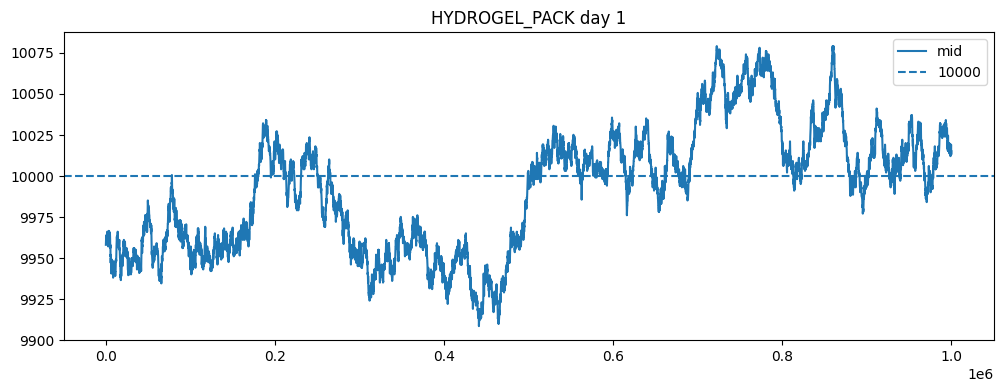

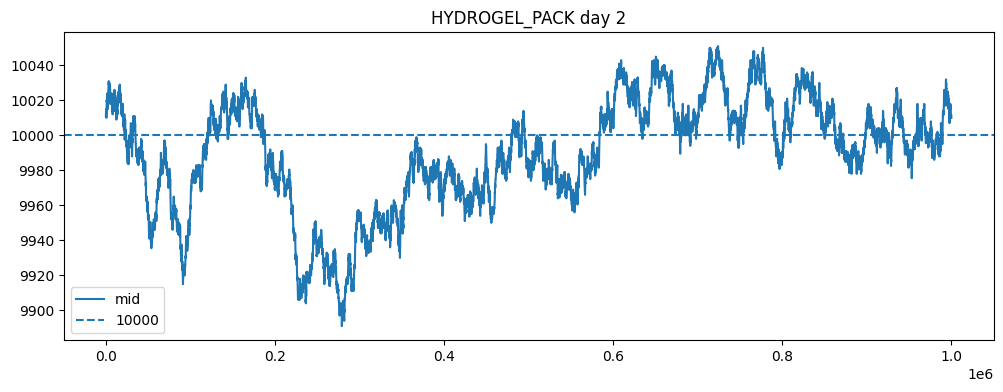

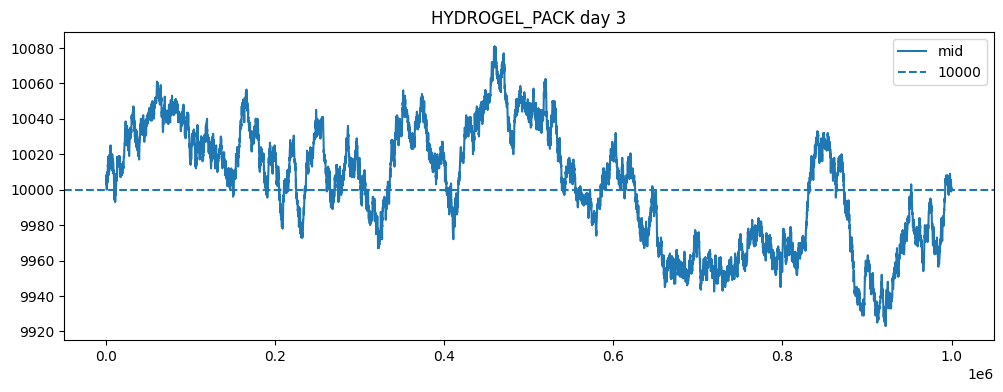

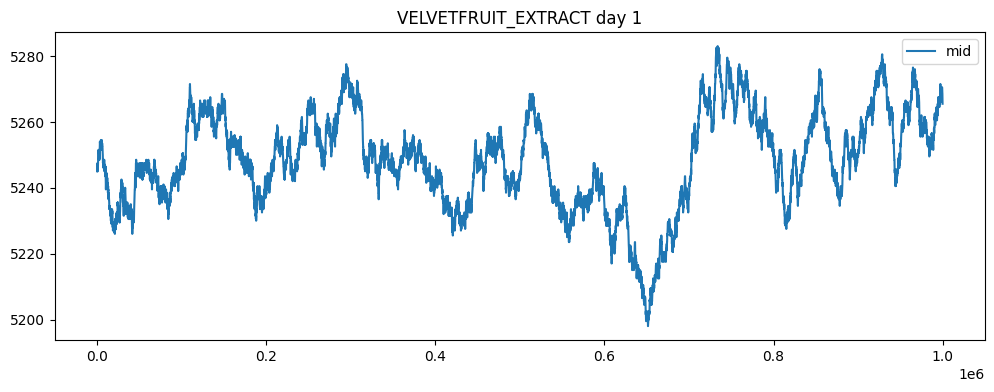

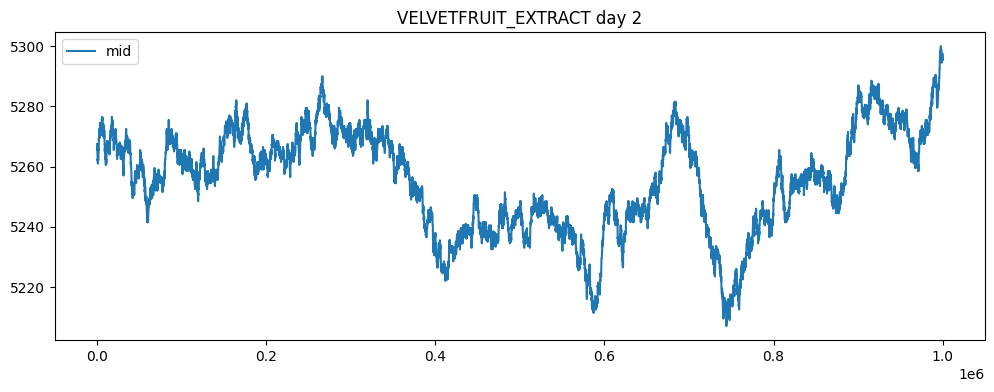

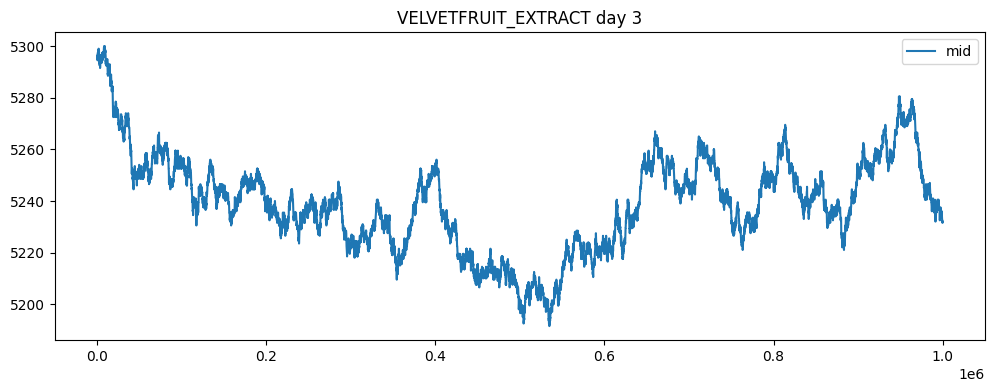

,strategy,product,total_pnl,trades,max_abs_pos,max_drawdown,params,day_1_pnl,day_2_pnl,day_3_pnl
0,HYD_anchor,HYDROGEL_PACK,141962.0,993,200,-20139.0,"{'edge': 8, 'size': 40}",44530.0,37316.0,58916.0
1,HYD_anchor,HYDROGEL_PACK,141962.0,993,200,-20139.0,"{'edge': 8, 'size': 80}",44530.0,37316.0,58916.0
2,HYD_anchor,HYDROGEL_PACK,141962.0,993,200,-20139.0,"{'edge': 8, 'size': 20}",44530.0,37316.0,58916.0
3,HYD_anchor,HYDROGEL_PACK,141049.0,856,200,-20300.0,"{'edge': 10, 'size': 80}",39263.0,36685.0,63901.0
4,HYD_anchor,HYDROGEL_PACK,141049.0,856,200,-20300.0,"{'edge': 10, 'size': 40}",39263.0,36685.0,63901.0
5,HYD_anchor,HYDROGEL_PACK,141049.0,856,200,-20300.0,"{'edge': 10, 'size': 20}",39263.0,36685.0,63901.0
6,HYD_wall_micro,HYDROGEL_PACK,140265.0,970,200,-20000.0,"{'edge': 3, 'size': 80}",45193.0,37340.0,56584.0
7,HYD_wall_micro,HYDROGEL_PACK,140265.0,970,200,-20000.0,"{'edge': 3, 'size': 40}",45193.0,37340.0,56584.0
8,HYD_wall_micro,HYDROGEL_PACK,140265.0,970,200,-20000.0,"{'edge': 3, 'size': 20}",45193.0,37340.0,56584.0
9,HYD_ema,HYDROGEL_PACK,138857.0,959,200,-20000.0,"{'edge': 3, 'size': 80}",45710.0,36807.0,55192.0


,strategy,product,total_pnl,trades,max_abs_pos,max_drawdown,params,day_1_pnl,day_2_pnl,day_3_pnl
0,VFE_ema_imb,VELVETFRUIT_EXTRACT,2960.0,317,62,-2513.5,"{'edge': 3, 'size': 20, 'imb_k': 8}",1411.5,1124.5,366.0
1,VFE_ema_imb,VELVETFRUIT_EXTRACT,2960.0,317,62,-2513.5,"{'edge': 3, 'size': 40, 'imb_k': 8}",1411.5,1124.5,366.0
2,VFE_ema_imb,VELVETFRUIT_EXTRACT,2583.0,192,47,-2083.5,"{'edge': 2, 'size': 10, 'imb_k': 0}",1601.0,1112.0,-154.0
3,VFE_ema_imb,VELVETFRUIT_EXTRACT,2437.0,965,81,-2287.5,"{'edge': 1.5, 'size': 40, 'imb_k': 8}",893.5,2096.0,-598.5
4,VFE_ema_imb,VELVETFRUIT_EXTRACT,2397.0,194,52,-2600.0,"{'edge': 2, 'size': 40, 'imb_k': 0}",1622.0,977.0,-226.0
5,VFE_ema_imb,VELVETFRUIT_EXTRACT,2318.0,311,70,-2647.0,"{'edge': 3, 'size': 40, 'imb_k': 12}",1404.0,1110.0,-244.0
6,VFE_ema_imb,VELVETFRUIT_EXTRACT,2318.0,311,70,-2647.0,"{'edge': 3, 'size': 20, 'imb_k': 12}",1404.0,1110.0,-244.0
7,VFE_ema_imb,VELVETFRUIT_EXTRACT,2255.0,792,43,-1907.5,"{'edge': 1.5, 'size': 5, 'imb_k': 4}",273.0,1394.0,572.0
8,VFE_ema_imb,VELVETFRUIT_EXTRACT,2253.0,309,57,-2407.0,"{'edge': 2, 'size': 10, 'imb_k': 2}",1107.5,836.0,271.5
9,VFE_ema_imb,VELVETFRUIT_EXTRACT,2225.0,715,65,-2462.5,"{'edge': 2, 'size': 20, 'imb_k': 8}",401.5,2004.0,-202.5


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,microprice,imbalance_l1,imbalance_l2,wall_mid,S_mid,S_micro,strike,tte,intrinsic,moneyness,iv,a0,a1,a2,n,smile_iv,smile_fair,smile_residual_px,smile_residual_iv
0,1,0,VEV_4000,1235,15,1232.0,27.0,NaN,NaN,1255,15,1258.0,27.0,NaN,NaN,1245.0,0.0,20,1245.00,0.00,0.0,1245.0,5245.0,5245.0,4000,0.016438,1245.0,0.270981,0.000001,0.255216,-0.081424,7.608093,8,0.791818,1245.544350,-0.544350,-0.791817
1,1,0,VEV_4500,737,6,735.0,13.0,NaN,NaN,753,6,755.0,13.0,NaN,NaN,745.0,0.0,16,745.00,0.00,0.0,745.0,5245.0,5245.0,4500,0.016438,745.0,0.153198,0.000001,0.255216,-0.081424,7.608093,8,0.421300,745.176734,-0.176734,-0.421299
2,1,0,VEV_5000,248,19,NaN,NaN,NaN,NaN,254,6,255.0,13.0,NaN,NaN,251.0,0.0,6,252.56,0.52,0.0,251.5,5245.0,5245.0,5000,0.016438,245.0,0.047837,0.262211,0.255216,-0.081424,7.608093,8,0.268731,251.635962,-0.635962,-0.006520
3,1,0,VEV_5100,163,19,NaN,NaN,NaN,NaN,167,6,168.0,13.0,NaN,NaN,165.0,0.0,4,166.04,0.52,0.0,165.5,5245.0,5245.0,5100,0.016438,145.0,0.028035,0.263924,0.255216,-0.081424,7.608093,8,0.258912,164.065672,0.934328,0.005012
4,1,0,VEV_5200,94,19,NaN,NaN,NaN,NaN,97,19,NaN,NaN,NaN,NaN,95.5,0.0,3,95.50,0.00,0.0,95.5,5245.0,5245.0,5200,0.016438,45.0,0.008617,0.264810,0.255216,-0.081424,7.608093,8,0.255079,92.986460,2.513540,0.009731


,strategy,product,total_pnl,trades,max_abs_pos,max_drawdown,params,day_1_pnl,day_2_pnl,day_3_pnl
0,voucher_smile,VEV_5300,2781.0,346,201,-6087.5,"{'edge': 2, 'size': 1}",-538.0,-625.0,4142.0
1,voucher_smile,VEV_5300,2539.0,64,113,-3842.0,"{'edge': 3, 'size': 2}",-267.0,-573.0,3488.0
2,voucher_smile,VEV_5300,2514.0,34,121,-4114.0,"{'edge': 3, 'size': 5}",-237.0,-615.0,3482.0
3,voucher_smile,VEV_5300,2426.0,565,251,-5623.0,"{'edge': 1.5, 'size': 1}",-615.0,197.0,3092.0
4,voucher_smile,VEV_5300,2342.0,23,135,-4585.0,"{'edge': 3, 'size': 10}",-340.0,-675.0,3492.0
5,voucher_smile,VEV_5300,2300.0,106,101,-3434.0,"{'edge': 3, 'size': 1}",-279.0,-509.0,3186.0
6,voucher_smile,VEV_5300,2295.0,202,213,-5706.5,"{'edge': 2, 'size': 2}",-499.0,-319.0,3322.0
7,voucher_smile,VEV_5300,2077.0,1205,295,-6947.0,"{'edge': 1, 'size': 1}",-857.0,-239.0,3466.0
8,voucher_smile,VEV_5300,1760.0,101,221,-4850.0,"{'edge': 2, 'size': 5}",-512.0,270.0,2218.0
9,voucher_smile,VEV_5300,1527.0,386,263,-5750.5,"{'edge': 1.5, 'size': 2}",-591.0,67.0,2310.0


,strategy,product,total_pnl,trades,max_abs_pos,max_drawdown,params,day_1_pnl,day_2_pnl,day_3_pnl
0,voucher_intrinsic,VEV_4500,83.0,6,5,-212.0,"{'buy_edge': 2, 'sell_edge': 1, 'size': 10}",0.0,10.0,73.0
1,voucher_intrinsic,VEV_4500,83.0,6,5,-212.0,"{'buy_edge': 2, 'sell_edge': 1, 'size': 20}",0.0,10.0,73.0
2,voucher_intrinsic,VEV_4500,83.0,6,5,-212.0,"{'buy_edge': 2, 'sell_edge': 1, 'size': 50}",0.0,10.0,73.0
3,voucher_intrinsic,VEV_4500,83.0,6,5,-212.0,"{'buy_edge': 2, 'sell_edge': 1, 'size': 5}",0.0,10.0,73.0
4,voucher_intrinsic,VEV_4000,83.0,6,5,-213.5,"{'buy_edge': 2, 'sell_edge': 1, 'size': 50}",0.0,10.0,73.0
5,voucher_intrinsic,VEV_4000,83.0,6,5,-213.5,"{'buy_edge': 2, 'sell_edge': 1, 'size': 20}",0.0,10.0,73.0
6,voucher_intrinsic,VEV_4000,83.0,6,5,-213.5,"{'buy_edge': 2, 'sell_edge': 1, 'size': 10}",0.0,10.0,73.0
7,voucher_intrinsic,VEV_4000,83.0,6,5,-213.5,"{'buy_edge': 2, 'sell_edge': 1, 'size': 5}",0.0,10.0,73.0
8,voucher_intrinsic,VEV_5400,0.0,0,0,0.0,"{'buy_edge': 5, 'sell_edge': 4, 'size': 50}",0.0,0.0,0.0
9,voucher_intrinsic,VEV_5400,0.0,0,0,0.0,"{'buy_edge': 5, 'sell_edge': 13, 'size': 20}",0.0,0.0,0.0


...

,product,role,name,n,mean_1,t_1,count_1,mean_5,t_5,count_5,mean_10,t_10,count_10,mean_20,t_20,count_20,mean_50,t_50,count_50,mean_100,t_100,count_100,mean_1000,t_1000,count_1000
5,VELVETFRUIT_EXTRACT,buyer,Mark 67,165,1.969697,26.207931,165,1.945455,12.941467,165,2.242424,10.157614,165,1.845455,5.967043,165,1.918182,3.917208,165,1.478659,2.011406,164,-0.310345,-0.176647,145
16,VELVETFRUIT_EXTRACT,pair,Mark 67->Mark 22,75,1.986667,18.083284,75,2.060000,9.305618,75,2.153333,6.612862,75,2.026667,4.158914,75,1.866667,2.674464,75,0.726667,0.656530,75,1.143939,0.387174,66
17,VELVETFRUIT_EXTRACT,pair,Mark 67->Mark 49,89,1.977528,19.331748,89,1.876404,9.111753,89,2.297753,7.545079,89,1.634831,4.112988,89,1.887640,2.731115,89,1.920455,1.969297,88,-1.448718,-0.687033,78
13,VELVETFRUIT_EXTRACT,pair,Mark 55->Mark 14,331,0.072508,1.169644,331,0.261329,2.152084,331,0.167674,1.014984,331,0.575529,2.713686,331,0.820669,2.247599,329,1.097561,2.219662,328,1.425249,1.140047,301
15,VELVETFRUIT_EXTRACT,pair,Mark 55->Mark 49,9,1.500000,6.363961,9,1.000000,1.851640,9,0.500000,0.569495,9,2.666667,2.537765,9,0.500000,0.263625,9,-2.500000,-0.949633,9,10.777778,1.279205,9
4,VELVETFRUIT_EXTRACT,buyer,Mark 55,598,0.010033,0.215773,598,0.198997,2.246478,598,0.012542,0.102322,598,0.408863,2.478876,598,0.386745,1.392003,596,0.531092,1.403872,595,1.801294,1.913986,541
14,VELVETFRUIT_EXTRACT,pair,Mark 55->Mark 22,14,1.428571,5.580119,14,1.714286,3.917175,14,1.714286,1.998932,14,2.035714,2.042842,14,3.392857,2.207100,14,1.500000,0.493270,14,5.791667,1.167438,12
8,VELVETFRUIT_EXTRACT,pair,Mark 22->Mark 49,7,1.428571,2.970443,7,2.142857,2.563073,7,2.285714,1.777778,7,2.714286,1.446286,7,5.142857,2.764464,7,5.571429,1.419277,7,13.071429,2.234923,7
2,VELVETFRUIT_EXTRACT,buyer,Mark 22,25,-0.340000,-1.099639,25,-0.400000,-0.653197,25,0.500000,0.706518,25,1.140000,1.343099,25,0.160000,0.116544,25,2.200000,1.075305,25,7.180000,1.753661,25
23,VELVETFRUIT_EXTRACT,seller,Mark 55,600,0.035833,0.755513,600,-0.051667,-0.577029,600,0.040833,0.335439,600,0.105833,0.618150,600,0.394472,1.525438,597,0.918487,2.504568,595,-1.546468,-1.650634,538


,product,role,name,n,mean_1,t_1,count_1,mean_5,t_5,count_5,mean_10,t_10,count_10,mean_20,t_20,count_20,mean_50,t_50,count_50,mean_100,t_100,count_100,mean_1000,t_1000,count_1000
7,HYDROGEL_PACK,seller,Mark 14,507,0.115385,1.189977,507,0.171598,0.923023,507,0.111440,0.410784,507,0.353057,0.926511,507,1.137081,1.953396,507,0.495050,0.607019,505,-1.603333,-0.888167,450
6,HYDROGEL_PACK,pair,Mark 38->Mark 22,8,3.187500,5.272281,8,3.187500,1.660034,8,3.437500,1.315772,8,1.312500,0.703414,8,0.125000,0.030137,8,-4.428571,-0.551807,7,-4.416667,-0.190438,6
0,HYDROGEL_PACK,buyer,Mark 14,496,0.191532,2.169101,496,0.071573,0.352948,496,0.231855,0.816253,496,0.233871,0.599398,496,0.614141,1.005628,495,0.892713,1.096862,494,1.337868,0.713663,441
3,HYDROGEL_PACK,pair,Mark 14->Mark 38,496,0.191532,2.169101,496,0.071573,0.352948,496,0.231855,0.816253,496,0.233871,0.599398,496,0.614141,1.005628,495,0.892713,1.096862,494,1.337868,0.713663,441
9,HYDROGEL_PACK,seller,Mark 38,507,-0.120316,-1.336624,507,-0.011834,-0.059115,507,-0.118343,-0.418539,507,-0.101578,-0.262480,507,-0.330040,-0.541689,506,-0.588119,-0.728014,505,-1.335920,-0.724945,451
8,HYDROGEL_PACK,seller,Mark 22,8,-3.187500,-5.272281,8,-3.187500,-1.660034,8,-3.437500,-1.315772,8,-1.312500,-0.703414,8,-0.125000,-0.030137,8,4.428571,0.551807,7,4.416667,0.190438,6
2,HYDROGEL_PACK,buyer,Mark 38,515,-0.064078,-0.656948,515,-0.119417,-0.641889,515,-0.056311,-0.208210,515,-0.327184,-0.869649,515,-1.117476,-1.939182,515,-0.548828,-0.676702,512,1.524123,0.845129,456
5,HYDROGEL_PACK,pair,Mark 38->Mark 14,507,-0.115385,-1.189977,507,-0.171598,-0.923023,507,-0.111440,-0.410784,507,-0.353057,-0.926511,507,-1.137081,-1.953396,507,-0.495050,-0.607019,505,1.603333,0.888167,450
1,HYDROGEL_PACK,buyer,Mark 22,11,-3.090909,-4.659283,11,-2.681818,-2.762928,11,-5.000000,-2.600974,11,-5.863636,-2.425172,11,-12.454545,-3.061691,11,-13.090909,-2.654429,11,1.250000,0.139036,10
4,HYDROGEL_PACK,pair,Mark 22->Mark 38,11,-3.090909,-4.659283,11,-2.681818,-2.762928,11,-5.000000,-2.600974,11,-5.863636,-2.425172,11,-12.454545,-3.061691,11,-13.090909,-2.654429,11,1.250000,0.139036,10


,day,timestamp,S_market,S_consensus,edge,dispersion,confidence,n,ret_1,ret_5,ret_10,ret_20,ret_50,ret_100
0,1,0,5245.0,5244.319560,-0.680440,7.162836,0.094996,10,0.5,2.5,2.0,6.5,7.0,0.5
1,1,100,5245.5,5245.172426,-0.327574,6.603281,0.049608,10,1.0,-0.5,2.0,4.5,6.5,-1.5
2,1,200,5246.5,5245.802917,-0.697083,7.369438,0.094591,10,1.0,-1.0,2.0,2.0,5.0,-3.0
3,1,300,5247.5,5246.678090,-0.821910,6.977006,0.117803,10,0.0,-2.0,2.0,2.0,6.0,-6.0
4,1,400,5247.5,5246.678090,-0.821910,6.977006,0.117803,10,0.0,-2.0,3.5,3.0,6.5,-8.0


option-implied edge corr ret 1 -0.15778453439437481
option-implied edge corr ret 5 -0.08218101532652623
option-implied edge corr ret 10 -0.058180610369044754
option-implied edge corr ret 20 -0.03488155832803958
option-implied edge corr ret 50 -0.01114709769278179
option-implied edge corr ret 100 0.011588830463056532


,strategy,product,total_pnl,trades,max_abs_pos,max_drawdown,params,day_1_pnl,day_2_pnl,day_3_pnl,bucket
0,HYD_anchor,HYDROGEL_PACK,141962.0,993,200,-20139.0,"{'edge': 8, 'size': 40}",44530.0,37316.0,58916.0,hyd
2,HYD_anchor,HYDROGEL_PACK,141962.0,993,200,-20139.0,"{'edge': 8, 'size': 20}",44530.0,37316.0,58916.0,hyd
1,HYD_anchor,HYDROGEL_PACK,141962.0,993,200,-20139.0,"{'edge': 8, 'size': 80}",44530.0,37316.0,58916.0,hyd
3,HYD_anchor,HYDROGEL_PACK,141049.0,856,200,-20300.0,"{'edge': 10, 'size': 80}",39263.0,36685.0,63901.0,hyd
5,HYD_anchor,HYDROGEL_PACK,141049.0,856,200,-20300.0,"{'edge': 10, 'size': 20}",39263.0,36685.0,63901.0,hyd
4,HYD_anchor,HYDROGEL_PACK,141049.0,856,200,-20300.0,"{'edge': 10, 'size': 40}",39263.0,36685.0,63901.0,hyd
6,HYD_wall_micro,HYDROGEL_PACK,140265.0,970,200,-20000.0,"{'edge': 3, 'size': 80}",45193.0,37340.0,56584.0,hyd
8,HYD_wall_micro,HYDROGEL_PACK,140265.0,970,200,-20000.0,"{'edge': 3, 'size': 20}",45193.0,37340.0,56584.0,hyd
7,HYD_wall_micro,HYDROGEL_PACK,140265.0,970,200,-20000.0,"{'edge': 3, 'size': 40}",45193.0,37340.0,56584.0,hyd
9,HYD_ema,HYDROGEL_PACK,138857.0,959,200,-20000.0,"{'edge': 3, 'size': 80}",45710.0,36807.0,55192.0,hyd


In [70]:
# Load
prices = load_price_files(data_dir=DATA_DIR)
trades = load_trade_files(data_dir=DATA_DIR)
display(prices.head())
display(prices["product"].value_counts())

# Diagnostics
display(diagnostic_table(prices))
plot_product(prices, HYD)
plot_product(prices, VFE)

# Product sweeps
hyd_results = sweep_hyd(prices)
vfe_results = sweep_vfe(prices)
display(hyd_results.head(20))
display(vfe_results.head(20))

# Voucher panel
panel = build_voucher_panel(prices, start_tte_days=6.0)
smile = fit_smile_by_timestamp(panel)
panel = attach_smile(panel, smile)
display(panel.head())

# Voucher strategy sweeps
smile_results = sweep_voucher_smile(panel)
intrinsic_results = sweep_intrinsic(panel)
pair_diag = pair_residual_diagnostics(panel)
delta_results = sweep_delta_lag(panel)
display(smile_results.head(20))
display(intrinsic_results.head(20))
display(pair_diag)
display(delta_results.head(20))

# Counterparty only on HYD/VFE
cp_vfe = counterparty_forward_returns(prices, trades, VFE)
cp_hyd = counterparty_forward_returns(prices, trades, HYD)
display(cp_vfe.sort_values("t_20", ascending=False).head(30) if not cp_vfe.empty else cp_vfe)
display(cp_hyd.sort_values("t_20", ascending=False).head(30) if not cp_hyd.empty else cp_hyd)

# Option-implied VFE
opt_vfe = option_implied_vfe_table(panel)
display(opt_vfe.head())
for h in [1,5,10,20,50,100]:
    print("option-implied edge corr ret", h, opt_vfe.edge.corr(opt_vfe[f"ret_{h}"]))

# Final ranking
all_rankings = []
for bucket, df in [("hyd", hyd_results), ("vfe", vfe_results), ("smile", smile_results), ("intrinsic", intrinsic_results), ("delta", delta_results)]:
    tmp = df.copy(); tmp["bucket"] = bucket; all_rankings.append(tmp)
final = pd.concat(all_rankings, ignore_index=True).sort_values("total_pnl", ascending=False)
display(final.head(50))
final.to_csv("round4_strategy_rankings.csv", index=False)

## 14. How to interpret results

Port only strategies that are positive across days, not just one lucky day.

Rules of thumb:

- High PnL + maxed inventory = dangerous.
- Counterparty alpha needs enough samples and stable sign.
- Cross-strike RV must beat crossing cost; residual mean reversion alone is not enough.
- If old Round 3 code loses, recalibrate HYD/VFE/voucher models before adding alphas.